# Gerchberg-Saxton phase retrieval

In this tutorial, we retrieve the phase of a laser pulse from measurements of the intensity at different planes. The number of planes should be greater than or equal to two. The phase retrieval can either be done using a modal decomposition or any propagator of choice. 

In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, epsilon_0

from lasy.laser import Laser
from lasy.profiles import CombinedLongitudinalTransverseProfile
from lasy.profiles.longitudinal import ContinuousWaveProfile
from lasy.profiles.transverse import (
    GaussianTransverseProfile
)

from lasy.optical_elements import Axiparabola, ParabolicMirror
from lasy.propagators import ABCD, CollinsSFFTPropagator

from lasy.utils.mode_decomposition import *
from lasy.utils.phase_retrieval import GerchbergSaxton

Next, we define the beam to be CW with a tophat profile in the transverse plane:

In [2]:
wavelength = 800e-9  # Laser wavelength in meters
omega0 = 2 * np.pi * c / wavelength
polarization = (1, 0)  # Linearly polarized in the x direction
peak_fluence = 1.5  # Energy of the laser pulse in joules
spot_size = 10e-3  # Spot size in the near-field: millimeter-scale
dimensions = "xyt"  # Use cylindrical geometry
lo = (-15. * spot_size, -15. * spot_size, None)  # Lower bounds of the simulation box
hi = (15. * spot_size, 15. * spot_size, None)  # Upper bounds of the simulation box
num_points = (100, 100, 1)  # Number of points in each dimension

long_prof = ContinuousWaveProfile(wavelength)
tran_prof = GaussianTransverseProfile(spot_size)
laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength, polarization, long_prof, tran_prof, peak_fluence=peak_fluence
)

laser = Laser(dimensions, lo, hi, num_points, laser_profile)

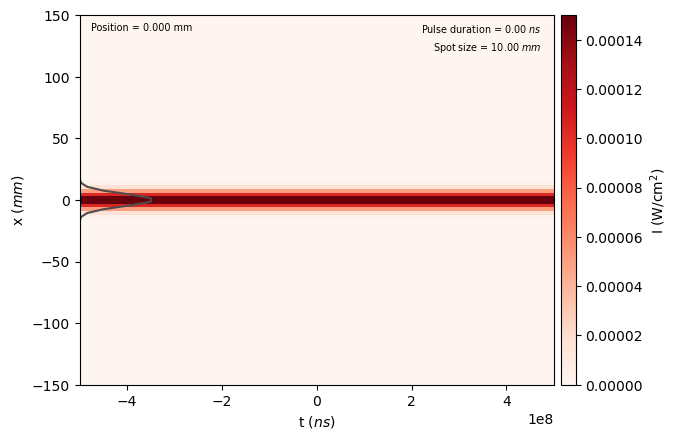

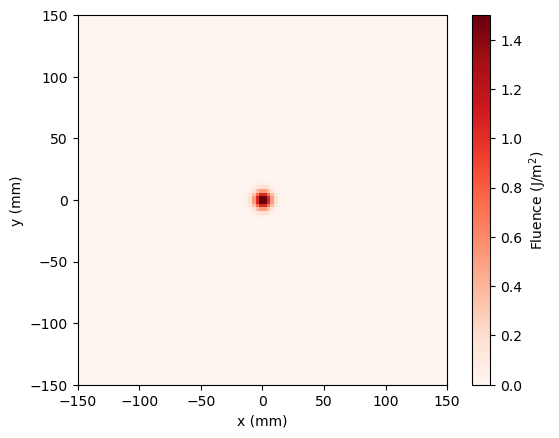

In [3]:
# Modal coefficients used to construct the beam
modes = {}
modes[(2, 3)] = 1 - 0.0j

# hermite_gauss_composition(
#    laser, spot_size, spot_size, modes, skipAsymmetricModes=False
# )

laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * laser.grid.dx[-1]
extent = (
    laser.grid.axes[0].min() * 1e3,
    laser.grid.axes[0].max() * 1e3,
    laser.grid.axes[1].min() * 1e3,
    laser.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")
plt.show()

fft of size 1: do nothing
fft of size 1: do nothing


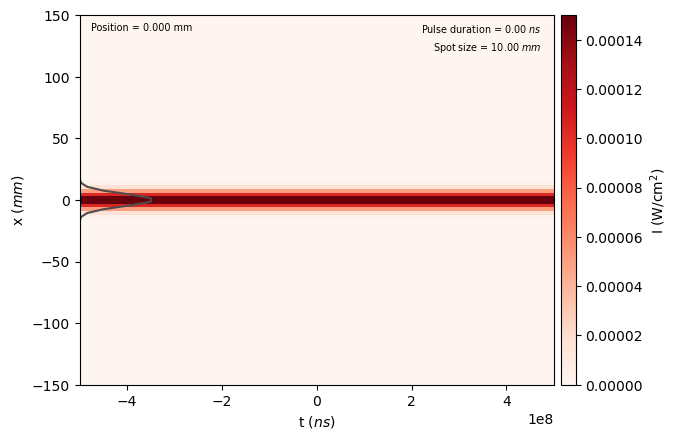

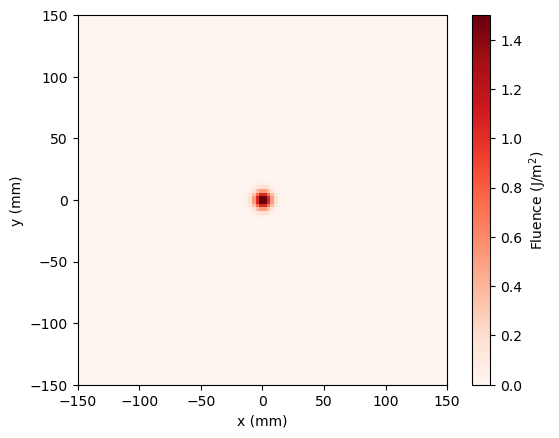

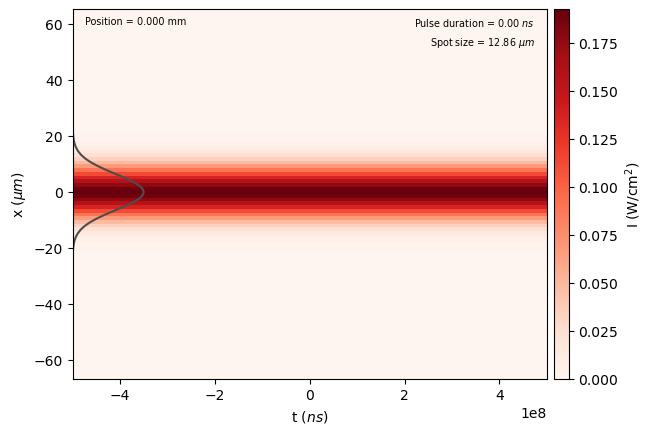

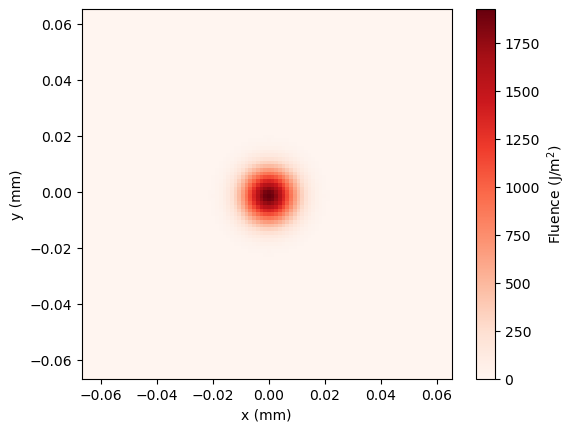

In [4]:
plane1 = deepcopy(laser)  # This is the field immediately prior to the lens
plane2 = deepcopy(laser)  # This will be the field at focus

f0 = 500e-3

prop = CollinsSFFTPropagator(dimensions, omega0)
abcd = ABCD()
abcd.add_lens(f0)
abcd.add_vacuum(f0)
prop.propagate(plane2.grid, abcd)

# Create instances of the propagator and ABCD matrix
plane1.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(plane1.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * plane1.grid.dx[-1]
extent = (
    plane1.grid.axes[0].min() * 1e3,
    plane1.grid.axes[0].max() * 1e3,
    plane1.grid.axes[1].min() * 1e3,
    plane1.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")


plane2.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(plane2.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * plane1.grid.dx[-1]
extent = (
    plane2.grid.axes[0].min() * 1e3,
    plane2.grid.axes[0].max() * 1e3,
    plane2.grid.axes[1].min() * 1e3,
    plane2.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")
plt.show()

In [5]:
gs = GerchbergSaxton([plane1,plane2], [0, f0], max_iter=2000)
phase1, phase2, errors = gs.retrieve_phase()

fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 1: do nothing
fft of size 

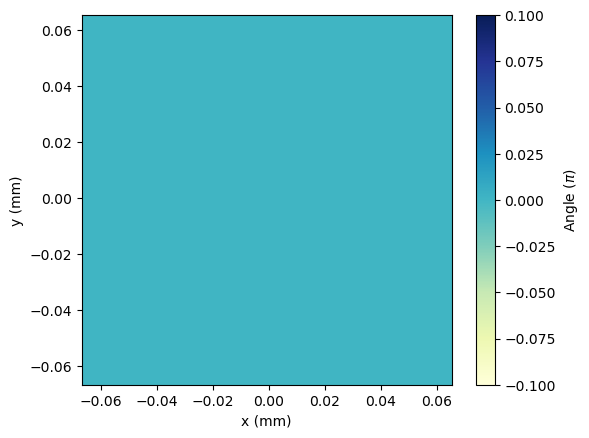

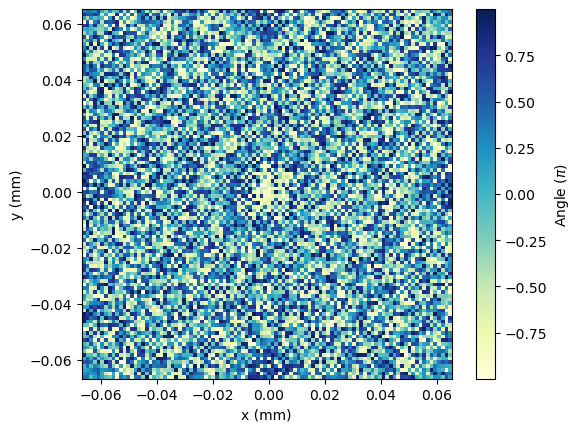

In [7]:
plt.figure()
plt.imshow(np.angle(laser.grid.get_temporal_field())/(np.pi), extent=extent, cmap="YlGnBu")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Angle ($\pi$)")
plt.show()

from unwrap import unwrap
plt.figure()
plt.imshow(phase1/(np.pi), extent=extent, cmap="YlGnBu")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Angle ($\pi$)")
plt.show()

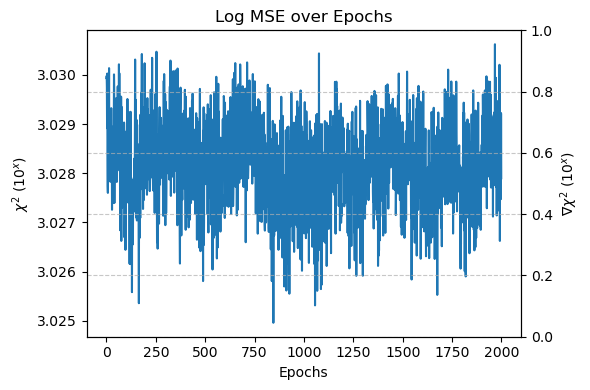

In [8]:
# Plot training and validation log MSE with 10^x format for the y-axis
def plot_log_mse(chi2):
    """
    Plots the logarithm (base 10) of training and validation MSE losses with 10^x format for the y-axis.

    Parameters:
        train_losses (list): Training MSE values over epochs.
        val_losses (list): Validation MSE values over epochs.
    """
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax2 = ax1.twinx()
    log_chi2 = np.log10(chi2+1e-8)
    
    ax1.plot(range(len(chi2)),log_chi2)
    # ax2.plot(range(len(chi2)),gradchi2, '--')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\chi^2$ ($10^x$)')
    ax2.set_ylabel(r'$\nabla \chi^2$ ($10^x$)')
    plt.title('Log MSE over Epochs')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Customize the y-axis ticks to show as 10^x
    # y_ticks = np.arange(int(np.floor(min(log_chi2.min(), log_chi2.min()))), 
    #                     int(np.ceil(max(log_chi2.max(), log_chi2.max()))) + 1)
    # ax1.set_yticks(y_ticks)
    # ax1.set_yticklabels([r"$10^{{{}}}$".format(int(tick)) for tick in y_ticks])
    
    plt.tight_layout()
    plt.show()
plot_log_mse(errors)